# Code for interleaved parallelism of multistep reconstruction method

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy

from radioimaging.util import util
from radioimaging.evaluation import evaluation
from radioimaging.visibility import weights, residual

from interleaved import *

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [10, 5]

/usr/lib/python3.10/abc.py:106: FutureWarning: xarray subclass Visibility should explicitly define __slots__
  cls = super().__new__(mcls, name, bases, namespace, **kwargs)


### Dataset parameters

In [2]:
dataset_name = "SGRA"
cut_center = 20
cut_halfwidth = 5
dataset_path = "../data4/"
num_pixels = 512
cell_size = 0.00001849451
weighting = 'uniform'
robustness = 0.0

small_baselines_msname = dataset_path + dataset_name + "_small_baselines_" + str(cut_center + cut_halfwidth) + ".ms"
long_baselines_msname = dataset_path + dataset_name + "_long_baselines_" + str(cut_center - cut_halfwidth) + ".ms"

### Load datasets and compute dirty images

In [3]:
from rascil.processing_components import create_visibility_from_ms

[vs] = create_visibility_from_ms(small_baselines_msname)
[vl] = create_visibility_from_ms(long_baselines_msname)

vs = weights.compute_weights(vs, num_pixels, cell_size, weighting, robustness=robustness)
vl = weights.compute_weights(vl, num_pixels, cell_size, weighting, robustness=robustness)

smallbaselines_est = create_empty_image(vs, num_pixels, cell_size)
longbaselines_est = create_empty_image(vl, num_pixels, cell_size)

small_psf = residual.compute_psf(vs, num_pixels, cell_size)
long_psf = residual.compute_psf(vl, num_pixels, cell_size)

gt = util.fromfits("../data/" + dataset_name + "_full_gt.fits")

create_visibility_from_ms: {'type': 'Measurement Set', 'subType': 'UVFITS', 'readme': 'This is a MeasurementSet Table holding measurements from a Telescope\nThis is a measurement set Table holding astronomical observations\n'}
create_visibility_from_ms: Reading unique fields [0], unique data descriptions [0]
create_visibility_from_ms: Found 118941 rows
create_visibility_from_ms: Found 1 channels
create_visibility_from_ms: Reading all 1 channels
create_visibility_from_ms: Observation from 2000-01-01 17:37:07.746 to 2000-01-01 21:35:07.746
create_visibility_from_ms: {'type': 'Measurement Set', 'subType': 'UVFITS', 'readme': 'This is a MeasurementSet Table holding measurements from a Telescope\nThis is a measurement set Table holding astronomical observations\n'}
create_visibility_from_ms: Reading unique fields [0], unique data descriptions [0]
create_visibility_from_ms: Found 169477 rows
create_visibility_from_ms: Found 1 channels
create_visibility_from_ms: Reading all 1 channels
create_

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)


create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -30.)>, starting frequency 1000000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 2638.861081 wavelengths
create_image_from_visibility: Critical cellsize = 0.000189 radians, 0.010856 degrees
create_image_from_visibility: Cellsize = 1.84945e-05 radians, 0.00105966 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)


create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -30.)>, starting frequency 1000000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 24331.536075 wavelengths
create_image_from_visibility: Critical cellsize = 0.000021 radians, 0.001177 degrees
create_image_from_visibility: Cellsize = 1.84945e-05 radians, 0.00105966 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)
create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -30.)>, starting frequency 1000000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 2638.861081 wavelengths
create_image_from_visibility: Critical cellsize = 0.000189 radians, 0.010856 degrees
create_image_from_visibility: Cellsize = 1.84945e-05 rad

### Reconstruction parameters

In [4]:
num_maj_cycles = 10
num_fista_iter = 100
initial_lambda_small = 0.05
initial_lambda_long = 0.05
lambda_mul_small = 2
lambda_mul_long = 2
vis_variance_window = 5
recon_variance_factor = 1000

wavelet_type_dict = {"daubechies" : 0, "iuwt" : 1}
wavelet_type = "daubechies"
wavelet_type_idx = wavelet_type_dict[wavelet_type]

### Perform reconstruction

In [5]:
lowvis_psnr = []
highvis_psnr = []
combined_psnr = []

for maj_cycle in range(num_maj_cycles):
    #compute residuals - FdagGdag(v - GFihat)
    small_residual = compute_residual(smallbaselines_est, vs, num_pixels, cell_size)
    long_residual = compute_residual(longbaselines_est, vl, num_pixels, cell_size)
    
    #Full deconvolution for both datasets. Does not take into account the second data fidelity term
    #for the first major cycle
    deconvolved_small = deconvolve(0, small_residual.pixels.data[0,0,:,:], small_psf.pixels.data[0,0,:,:],\
                                   [smallbaselines_est.pixels.data[0,0,:,:], longbaselines_est.pixels.data[0,0,:,:]],\
                                   num_fista_iter, wavelet_type_idx, maj_cycle, initial_lambda_small, \
                                   lambda_mul_small, cut_center, cut_halfwidth, vis_variance_window, recon_variance_factor)
    
    deconvolved_long = deconvolve(1, long_residual.pixels.data[0,0,:,:], long_psf.pixels.data[0,0,:,:],\
                                  [smallbaselines_est.pixels.data[0,0,:,:], longbaselines_est.pixels.data[0,0,:,:]], \
                                  num_fista_iter, wavelet_type_idx, maj_cycle, initial_lambda_long,\
                                  lambda_mul_long, cut_center, cut_halfwidth, vis_variance_window, recon_variance_factor)
    
    #add current deconvolved to current sky estimate
    smallbaselines_est = add_to_image(smallbaselines_est, deconvolved_small)
    longbaselines_est = add_to_image(longbaselines_est, deconvolved_long)
    
    recombined = (smallbaselines_est.pixels.data[0,0,:,:] + longbaselines_est.pixels.data[0,0,:,:]) / 2
    
    #lowvis_psnr.append(helpers.compute_snr(gt, smallbaselines_est.pixels.data[0,0,:,:]))
    #highvis_psnr.append(helpers.compute_snr(gt, longbaselines_est.pixels.data[0,0,:,:]))
    #combined_psnr.append(helpers.compute_snr(gt, recombined))
    
    lowvis_psnr.append(helpers.compute_rmse(gt, smallbaselines_est.pixels.data[0,0,:,:]))
    highvis_psnr.append(helpers.compute_rmse(gt, longbaselines_est.pixels.data[0,0,:,:]))
    combined_psnr.append(helpers.compute_rmse(gt, recombined))
    
    
    #helpers.plotNImages([smallbaselines_est.pixels.data[0,0,:,:], longbaselines_est.pixels.data[0,0,:,:]], ["small", "long"], cmap=cmap)
    #helpers.plotNImages([recombined], ["recombined"], cmap=cmap)

create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -30.)>, starting frequency 1000000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 2638.861081 wavelengths
create_image_from_visibility: Critical cellsize = 0.000189 radians, 0.010856 degrees
create_image_from_visibility: Cellsize = 1.84945e-05 radians, 0.00105966 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)
create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -30.)>, starting frequency 1000000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 24331.536075 wavelengths
create_image_from_visibility: Critical cellsize = 0.000021 radians, 0.001177 degrees
create_image_from_visibility: Cellsize = 1.84945e-05 rad

create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -30.)>, starting frequency 1000000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 24331.536075 wavelengths
create_image_from_visibility: Critical cellsize = 0.000021 radians, 0.001177 degrees
create_image_from_visibility: Cellsize = 1.84945e-05 radians, 0.00105966 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)
create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -30.)>, starting frequency 1000000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 2638.861081 wavelengths
create_image_from_visibility: Critical cellsize = 0.000189 radians, 0.010856 degrees
create_image_from_visibility: Cellsize = 1.84945e-05 radians, 0.00105966 degrees
create_image_from_visibility: image shape is (1, 

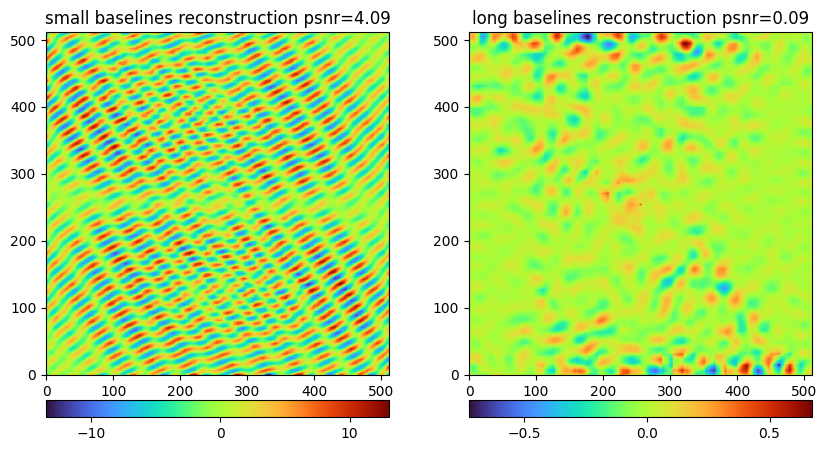

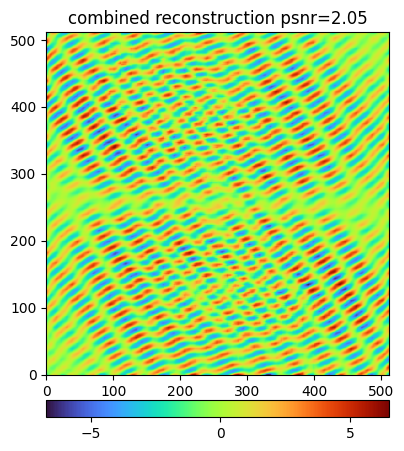

In [6]:
util.plotNImages([smallbaselines_est.pixels.data[0,0,:,:], longbaselines_est.pixels.data[0,0,:,:]], \
                    ["small baselines reconstruction psnr=" + "{:.2f}".format(lowvis_psnr[-1]), "long baselines reconstruction psnr=" + "{:.2f}".format(highvis_psnr[-1])], cmap=cmap)

util.plotNImages([recombined], ["combined reconstruction psnr=" + "{:.2f}".format(combined_psnr[-1])], cmap=cmap)

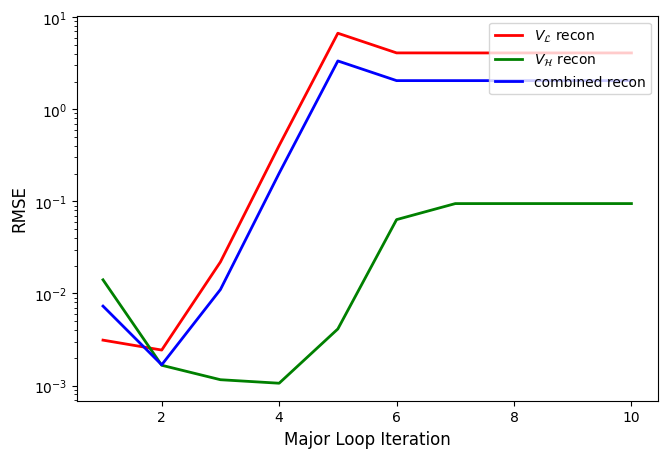

In [7]:
matplotlib.rcParams['figure.figsize'] = [7.5, 5]

plt.plot(range(1, 11), lowvis_psnr, c='r', label="${V}_\mathcal{L}$ recon", lw=2)
plt.plot(range(1, 11), highvis_psnr, c='g', label="${V}_\mathcal{H}$ recon", lw=2)
plt.plot(range(1, 11), combined_psnr, c='b', label="combined recon", lw=2)


plt.xlabel("Major Loop Iteration", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.yscale('log')
plt.legend(loc="upper right")

plt.savefig("../figures/interleaved.png", bbox_inches='tight')